# Experiment 2 Data Mining ATRs With Differing Expected Returns

> **L’Eurêka final :** le **data mining** peut réellement sélectionner des règles avec du mérite, mais seulement quand l’échantillon est assez grand pour séparer le **talent réel** du **bruit d’échantillonnage**.

Ce notebook transforme le concept EBTA en simulation Python.

L’objectif est de visualiser pourquoi, dans l’expérience 2 d’Aronson, la meilleure règle sélectionnée par **data mining** peut être réellement supérieure à une règle choisie au hasard, mais uniquement quand le nombre d’observations est élevé.


## 1. Idée centrale

Dans l’expérience 1, toutes les règles avaient un mérite nul. Le gagnant du backtest était donc forcément un gagnant par chance.

Dans l’expérience 2, Aronson rend le monde plus réaliste : les règles n’ont pas toutes le même **rendement attendu**.

Certaines règles sont médiocres, beaucoup sont ordinaires, et une très petite minorité est réellement exceptionnelle.

> Le problème du trader quant n’est donc pas seulement de chercher beaucoup.  
> Le problème est de chercher beaucoup **avec assez de données** pour que le meilleur score observé corresponde au meilleur mérite réel.

En notation simple :

$$
P_{obs} = P_{real} + H
$$

où :

- $P_{obs}$ est la performance observée dans le **backtest**.
- $P_{real}$ est le mérite réel de la règle.
- $H$ est le bruit dû au hasard.

Quand l’échantillon est petit, $H$ domine.

Quand l’échantillon est grand, $P_{real}$ devient plus visible.


## 2. Analogie pratique trading

Imagine un univers de $M$ règles de trading.

Chaque règle possède un rendement attendu annuel inconnu :

$$
ER_i
$$

Le backtest observe seulement une version bruitée de ce rendement :

$$
Score_i = ER_i + \epsilon_i
$$

Le data mining sélectionne :

$$
i^* = \arg\max_i(Score_i)
$$

La vraie question devient :

> Est-ce que la règle $i^*$ est réellement meilleure que la moyenne, ou est-ce seulement une règle chanceuse ?

La réponse dépend principalement de $N$, le nombre d’observations utilisées pour calculer le score.


In [1]:
# Imports de base

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 3. Modéliser une distribution de mérites type “Bill Gates”

Aronson explique que le talent des règles peut ressembler à une distribution de richesse :

- beaucoup de règles faibles ou ordinaires ;
- quelques règles bonnes ;
- une infime minorité de règles exceptionnelles.

Nous allons approximer cette idée avec une distribution **lognormale** des rendements attendus annuels.

On calibre l’exemple pour obtenir :

| Élément | Valeur pédagogique |
|---|---:|
| Rendement attendu moyen de l’univers | $1.4\%$ par an |
| Règle extrêmement rare | $19\%$ ou plus par an |
| Fréquence approximative | $1$ sur $10\,000$ |

Ce n’est pas une reproduction exacte du livre, mais une simulation pédagogique qui illustre le mécanisme.


In [2]:
# Calibration pédagogique d'une distribution lognormale

mean_er = 0.014       # 1.4% annuel
rare_er = 0.19        # 19% annuel
z_9999 = 3.71901649   # quantile normal environ 99.99%

# On résout approximativement une lognormale positive :
# mean = exp(mu + 0.5*sigma²)
# q_9999 = exp(mu + sigma*z)
ratio = rare_er / mean_er
sigma_ln = z_9999 - np.sqrt(z_9999**2 - 2 * np.log(ratio))
mu_ln = np.log(mean_er) - 0.5 * sigma_ln**2

sigma_ln, mu_ln

(np.float64(0.783858884725376), np.float64(-4.575915324948334))

In [3]:
def sample_true_expected_returns(n_rules: int, rng: np.random.Generator) -> np.ndarray:
    """Tire les mérites réels annuels des règles."""
    return rng.lognormal(mean=mu_ln, sigma=sigma_ln, size=n_rules)


sample = sample_true_expected_returns(100_000, rng)

summary = pd.Series(sample).describe(percentiles=[0.5, 0.9, 0.99, 0.999, 0.9999])
summary

count    100,000.0000
mean           0.0140
std            0.0131
min            0.0003
50%            0.0102
90%            0.0281
99%            0.0646
99.9%          0.1167
99.99%         0.2136
max            0.5216
dtype: float64

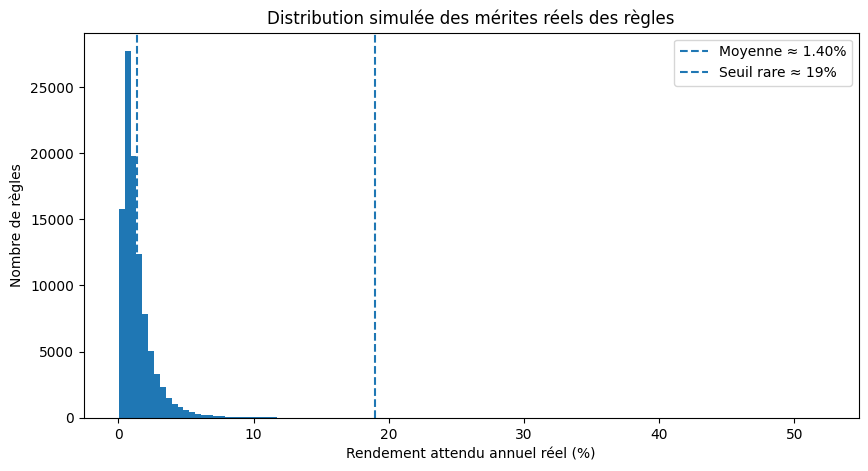

In [4]:
plt.figure(figsize=(10, 5))
plt.hist(sample * 100, bins=120)
plt.axvline(sample.mean() * 100, linestyle="--", label=f"Moyenne ≈ {sample.mean()*100:.2f}%")
plt.axvline(rare_er * 100, linestyle="--", label="Seuil rare ≈ 19%")
plt.title("Distribution simulée des mérites réels des règles")
plt.xlabel("Rendement attendu annuel réel (%)")
plt.ylabel("Nombre de règles")
plt.legend()
plt.show()

## 4. Simuler le processus de data mining

Pour chaque expérience :

1. On crée $M$ règles.
2. Chaque règle reçoit un vrai rendement attendu $ER_i$.
3. On génère un score backtesté bruité.
4. On sélectionne la règle avec le meilleur score observé.
5. On regarde son vrai mérite réel.

Le score observé est simulé ainsi :

$$
Score_i = ER_i + \epsilon_i
$$

Le bruit baisse quand $N$ augmente :

$$
\sigma_{score} = \frac{12 \times \sigma_{mensuel}}{\sqrt{N}}
$$

Donc :

- avec $N=2$ mois, le score est très bruité ;
- avec $N=1000$ mois, le score devient beaucoup plus fiable.


In [5]:
def run_data_mining_experiment(
    n_rules: int,
    n_observations: int,
    n_trials: int = 2_000,
    monthly_noise: float = 0.05,
    rng_seed: int = 123
) -> pd.DataFrame:
    """
    Simule le data mining de règles avec mérites différents.

    n_rules:
        Nombre de règles candidates testées.

    n_observations:
        Nombre de mois utilisés pour calculer le score backtesté.

    monthly_noise:
        Volatilité mensuelle idiosyncratique autour du mérite réel.

    Retourne un DataFrame avec :
        - true_er_selected : mérite réel de la règle gagnante
        - observed_score_selected : score backtesté de la règle gagnante
        - true_er_random : mérite réel d'une règle choisie au hasard
        - data_mining_bias : score observé - mérite réel
    """
    local_rng = np.random.default_rng(rng_seed)
    score_noise_std = monthly_noise * 12 / np.sqrt(n_observations)

    rows = []

    for _ in range(n_trials):
        true_er = sample_true_expected_returns(n_rules, local_rng)

        observed_score = true_er + local_rng.normal(
            loc=0.0,
            scale=score_noise_std,
            size=n_rules
        )

        selected_idx = np.argmax(observed_score)
        random_idx = local_rng.integers(0, n_rules)

        rows.append({
            "n_rules": n_rules,
            "n_observations": n_observations,
            "true_er_selected": true_er[selected_idx],
            "observed_score_selected": observed_score[selected_idx],
            "true_er_random": true_er[random_idx],
            "data_mining_bias": observed_score[selected_idx] - true_er[selected_idx],
        })

    return pd.DataFrame(rows)

## 5. Comparaison : petit échantillon vs grand échantillon

Nous allons comparer deux mondes :

| Monde | Interprétation |
|---|---|
| $N=2$ mois | Le bruit domine presque tout |
| $N=1000$ mois | Le mérite réel devient visible |

On fait varier le nombre de règles testées pour voir si le data mining parvient à trouver du vrai talent.


In [6]:
n_rules_grid = [10, 30, 100, 300, 1_000, 3_000, 10_000]
n_observations_grid = [2, 1_000]

all_results = []

for n_obs in n_observations_grid:
    for n_rules in n_rules_grid:
        result = run_data_mining_experiment(
            n_rules=n_rules,
            n_observations=n_obs,
            n_trials=1_000,
            rng_seed=10_000 + n_obs + n_rules
        )
        all_results.append(result)

results = pd.concat(all_results, ignore_index=True)

summary_results = (
    results
    .groupby(["n_observations", "n_rules"])
    .agg(
        selected_true_er_mean=("true_er_selected", "mean"),
        random_true_er_mean=("true_er_random", "mean"),
        observed_score_mean=("observed_score_selected", "mean"),
        bias_mean=("data_mining_bias", "mean"),
    )
    .reset_index()
)

summary_results_percent = summary_results.copy()
for col in ["selected_true_er_mean", "random_true_er_mean", "observed_score_mean", "bias_mean"]:
    summary_results_percent[col] = summary_results_percent[col] * 100

summary_results_percent

,n_observations,n_rules,selected_true_er_mean,random_true_er_mean,observed_score_mean,bias_mean
0,2,10,1.4638,1.3881,68.1153,66.6515
1,2,30,1.5217,1.4015,87.5298,86.0081
2,2,100,1.5121,1.3526,108.6586,107.1464
3,2,300,1.6408,1.3385,123.0231,121.3823
4,2,1000,1.5563,1.3901,138.0430,136.4867
5,2,3000,1.5871,1.4627,151.9469,150.3598
6,2,10000,1.6270,1.4245,165.4260,163.7990
7,1000,10,2.8820,1.4090,5.1803,2.2984
8,1000,30,4.2912,1.4670,6.7297,2.4384
9,1000,100,6.9032,1.4041,9.1114,2.2082


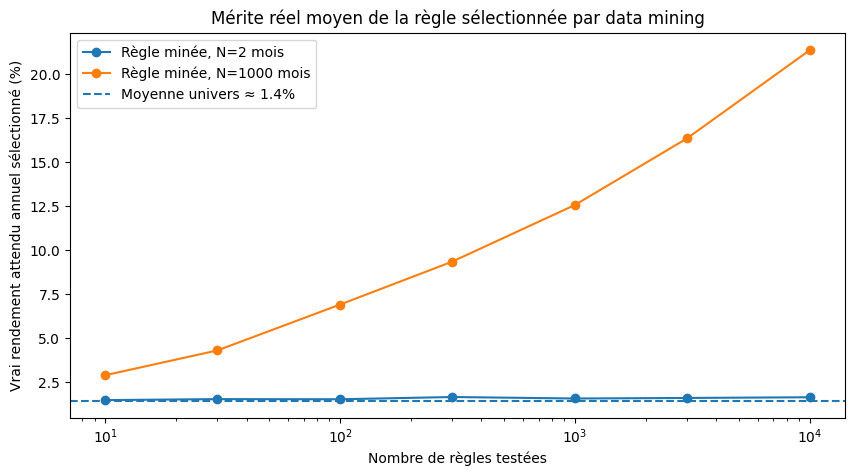

In [7]:
plt.figure(figsize=(10, 5))

for n_obs in n_observations_grid:
    subset = summary_results[summary_results["n_observations"] == n_obs]
    plt.plot(
        subset["n_rules"],
        subset["selected_true_er_mean"] * 100,
        marker="o",
        label=f"Règle minée, N={n_obs} mois"
    )

plt.axhline(mean_er * 100, linestyle="--", label="Moyenne univers ≈ 1.4%")
plt.xscale("log")
plt.title("Mérite réel moyen de la règle sélectionnée par data mining")
plt.xlabel("Nombre de règles testées")
plt.ylabel("Vrai rendement attendu annuel sélectionné (%)")
plt.legend()
plt.show()

## 6. Lecture du graphique

Avec $N=1000$ mois, la courbe monte quand le nombre de règles augmente.

Cela signifie que le data mining trouve réellement des règles de meilleur mérite.

Avec $N=2$ mois, la courbe reste proche de la moyenne de l’univers.

Cela signifie que le gagnant du backtest n’est pas vraiment le plus talentueux : il est surtout le plus chanceux.

> Le data mining n’est donc pas mauvais en soi.  
> Il devient dangereux quand le nombre d’observations est trop faible par rapport au nombre de règles testées.


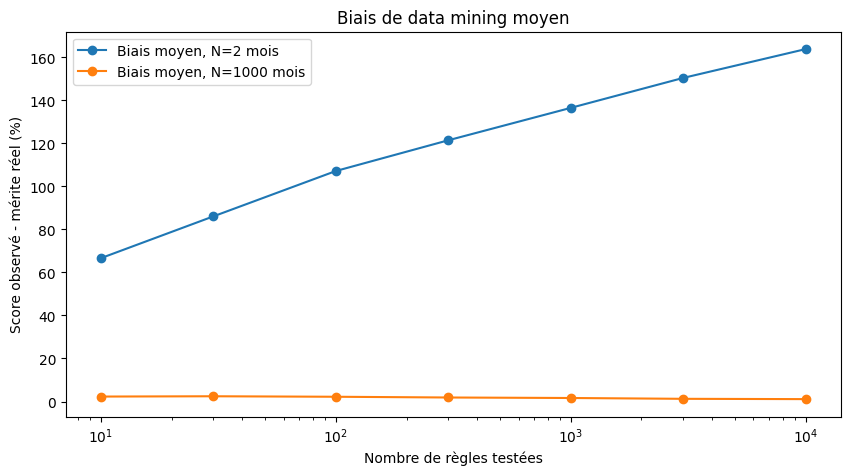

In [8]:
plt.figure(figsize=(10, 5))

for n_obs in n_observations_grid:
    subset = summary_results[summary_results["n_observations"] == n_obs]
    plt.plot(
        subset["n_rules"],
        subset["bias_mean"] * 100,
        marker="o",
        label=f"Biais moyen, N={n_obs} mois"
    )

plt.xscale("log")
plt.title("Biais de data mining moyen")
plt.xlabel("Nombre de règles testées")
plt.ylabel("Score observé - mérite réel (%)")
plt.legend()
plt.show()

## 7. Interprétation EBTA

Le biais de data mining vient de l’écart entre :

$$
\text{Performance backtestée du gagnant}
-
\text{Mérite réel du gagnant}
$$

Même quand le data mining trouve une vraie bonne règle, son score observé reste souvent trop optimiste.

C’est la nuance importante :

| Situation | Conclusion |
|---|---|
| Grand $N$ | La règle sélectionnée peut avoir du vrai mérite |
| Petit $N$ | La règle sélectionnée ressemble à un gagnant par chance |
| Beaucoup de règles testées | La chance extrême devient plus probable |
| Mérite variable entre règles | Une partie de la victoire peut être réellement méritée |
| Score backtesté très élevé | Ne prouve pas directement un alpha futur équivalent |

> Une règle peut être à la fois **réellement bonne** et **surestimée par son backtest**.


## 8. Exemple concret pour ton trading

Supposons que tu testes 10 000 variantes d’une stratégie ICT / engulfing :

- différentes heures de session ;
- différents filtres de liquidité ;
- différents ratios risque/rendement ;
- différents timeframes ;
- différents seuils de volatilité ;
- différentes conditions de momentum.

Si tu n’as que 30 trades ou 2 mois d’historique, le meilleur résultat est presque impossible à interpréter.

Mais si tu as plusieurs années de données, beaucoup d’observations, et une méthodologie propre, alors le data mining peut devenir un outil de sélection utile.

La règle pratique :

> Plus tu augmentes le nombre de variantes testées, plus tu dois augmenter le nombre d’observations indépendantes utilisées pour juger les variantes.


## 9. Checklist EBTA anti-illusion

Avant de croire une règle gagnante issue d’un backtest massif :

| Question | Pourquoi c’est important |
|---|---|
| Combien de règles ai-je testées ? | Plus $M$ est grand, plus le meilleur score peut être chanceux |
| Combien d’observations ai-je ? | Plus $N$ est faible, plus le bruit domine |
| La règle gagnante reste-t-elle bonne hors échantillon ? | Vérifie que le mérite n’était pas seulement local |
| Le score est-il stable par sous-période ? | Évite une règle portée par un seul régime |
| La logique économique est-elle crédible ? | Réduit le risque d’optimisation aveugle |
| Ai-je corrigé le biais de data mining ? | Indispensable pour comparer beaucoup de règles |

> **L’Eurêka final :** le data mining est une boussole, pas une preuve absolue. Il indique où chercher l’alpha, mais seul un échantillon large et une validation robuste permettent de distinguer l’or du bruit.


## 10. Mini-expérience à modifier

Tu peux changer les paramètres suivants :

- `n_rules_grid` : nombre de règles testées ;
- `n_observations_grid` : taille de l’échantillon ;
- `monthly_noise` : volatilité autour du mérite réel ;
- `n_trials` : nombre de répétitions Monte Carlo.

Essaie par exemple :

$$
N = 30, 100, 300, 1000
$$

Tu verras progressivement la transition entre un monde dominé par la chance et un monde où le mérite devient visible.


In [9]:
# Expérience bonus : plusieurs tailles d'échantillon

bonus_n_observations = [2, 30, 100, 300, 1_000]
bonus_n_rules = 10_000

bonus_results = []

for n_obs in bonus_n_observations:
    df = run_data_mining_experiment(
        n_rules=bonus_n_rules,
        n_observations=n_obs,
        n_trials=2_000,
        rng_seed=50_000 + n_obs
    )
    bonus_results.append(df)

bonus_results = pd.concat(bonus_results, ignore_index=True)

bonus_summary = (
    bonus_results
    .groupby("n_observations")
    .agg(
        selected_true_er_mean=("true_er_selected", "mean"),
        random_true_er_mean=("true_er_random", "mean"),
        observed_score_mean=("observed_score_selected", "mean"),
        bias_mean=("data_mining_bias", "mean"),
    )
    .reset_index()
)

bonus_summary_percent = bonus_summary.copy()
for col in ["selected_true_er_mean", "random_true_er_mean", "observed_score_mean", "bias_mean"]:
    bonus_summary_percent[col] = bonus_summary_percent[col] * 100

bonus_summary_percent

,n_observations,selected_true_er_mean,random_true_er_mean,observed_score_mean,bias_mean
0,2,1.5885,1.3404,164.8025,163.2140
1,30,4.2970,1.4609,44.5088,40.2118
2,100,12.6550,1.3519,28.0256,15.3705
3,300,19.6906,1.3505,23.5725,3.8819
4,1000,20.9996,1.3951,22.0053,1.0057


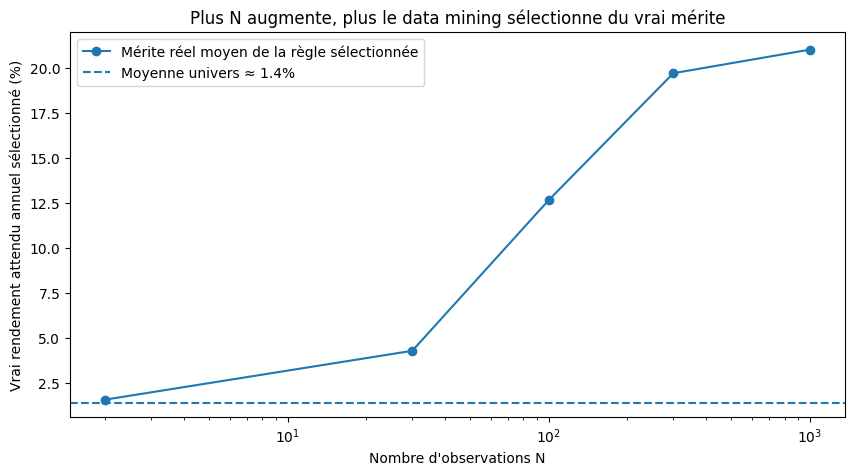

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(
    bonus_summary["n_observations"],
    bonus_summary["selected_true_er_mean"] * 100,
    marker="o",
    label="Mérite réel moyen de la règle sélectionnée"
)
plt.axhline(mean_er * 100, linestyle="--", label="Moyenne univers ≈ 1.4%")
plt.xscale("log")
plt.title("Plus N augmente, plus le data mining sélectionne du vrai mérite")
plt.xlabel("Nombre d'observations N")
plt.ylabel("Vrai rendement attendu annuel sélectionné (%)")
plt.legend()
plt.show()

## 11. Résumé final

Cette expérience montre trois choses essentielles :

> 1. Le **data mining** peut fonctionner quand les règles ont des mérites différents.
> 2. Le meilleur backtest peut réellement contenir plus d’alpha que la moyenne.
> 3. Mais cette capacité dépend fortement de la taille de l’échantillon.

En langage trader :

> Si tu fais jouer les stratégies sur trop peu de données, tu sélectionnes le hasard.  
> Si tu les fais jouer sur assez de données, tu commences à sélectionner le talent.


## Annexe — Source originale collée

Le texte ci-dessous est la source fournie par l’utilisateur pour générer ce notebook.

---


### **EXPERIMENT 2 : DATA MINING ATRs WITH DIFFERING EXPECTED RETURNS**

Voici l’analyse technique de la deuxième série d’expériences d’Aronson, qui valide le principe même du minage de données tout en soulignant ses limites critiques liées à la taille de l’échantillon.

#### **(AJOUT) Idées clés :**
*   **Réalisme expérimental :** Contrairement à l’expérience 1 (mérite nul), cette étude introduit de la "véritable or" (règles avec pouvoir prédictif) de manière rare dans l'univers de test.
*   **Validation du minage :** Aronson confirme que le minage de données est une méthode de recherche valide : la règle qui a le mieux performé par le passé a statistiquement plus de chances d'être la meilleure dans le futur.
*   **La condition sine qua non :** Cette efficacité est totalement dépendante du nombre d'observations. Avec trop peu de données, le minage ne vaut pas mieux qu'un choix au hasard.
*   **Distribution "Bill Gates" :** Le talent est modélisé comme la richesse dans la société : une immense majorité de règles médiocres et une infime minorité de règles exceptionnelles.

#### **Référence :**
*Experiment 2: Data Mining ATRs with Differing Expected Returns*, Chapitre 6, pages 307 à 309.

#### **Citation Directe :**
« Data mining must, at the very least, pass this minimal test of efficacy to establish that it is a reasonable research approach. [...] Fortunately... the answer is a qualified yes. The qualification relates to the number of observations that are used. » (Page 307-309).

---

#### **Vision Macro :**
L'enjeu est de répondre à la question existentielle du trader algorithmique : « Est-ce que chercher la meilleure stratégie parmi des milliers a un sens ? ». David Aronson démontre que le minage de données n'est pas une "chasse aux fantômes" si l'on respecte la rigueur statistique. L'objectif est de prouver que le processus de sélection identifie réellement du mérite et non uniquement de la chance. C'est le passage d'une vision où tout est hasard à une vision où le minage agit comme un filtre efficace pour extraire la rareté (l'alpha) du bruit.

---

#### **Vision Micro :**

1.  **Modélisation du Mérite (Figure 6.42) :**
    *   Aronson utilise une distribution de probabilité pour les Rendements Attendus ($ER$) inspirée de la distribution des richesses.
    *   La moyenne de l'univers est de **+1,4 %** par an.
    *   Une règle affichant **+19 %** ou plus n'apparaît qu'une fois sur 10 000.
2.  **Le test de la "Boussole" (Figure 6.43) :**
    *   L'ordinateur compare le rendement attendu de la règle sélectionnée par minage à celui d'une règle choisie au hasard.
    *   **Résultat avec $N=1000$ mois :** Plus on teste de règles, plus le mérite réel de la règle sélectionnée grimpe (jusqu'à **+10 %** par an), prouvant que le minage "trouve" effectivement les meilleures règles.
    *   **Résultat avec $N=2$ mois :** La courbe reste plate à +1,4 %. Le minage échoue totalement à identifier le talent car le hasard des deux mois occulte tout signal.
3.  **L'impact sur le Biais :** Dans un univers de mérite variable, le biais de minage (l'écart entre le profit backtesté et le profit réel) est plus faible que dans un univers de mérite nul, car la victoire de la règle est en partie "méritée" par son talent intrinsèque.

---

#### **(AJOUT) Résumé Simplifié :**
Imagine que tu cherches un champion de tennis dans une foule de 10 000 personnes. Si tu les fais jouer un seul point (échantillon faible), le gagnant sera juste un chanceux. Si tu les fais jouer 1 000 matchs (échantillon large), le gagnant sera forcément le meilleur joueur. Aronson nous dit : l'ordinateur est un super recruteur, il trouvera le champion, mais seulement si tu lui donnes assez de matchs (de données historiques) pour juger.

---

#### **Actions Concrètes :**
*   **Ne jamais miner sur de petits historiques :** Si vous n'avez que quelques mois ou quelques dizaines de trades, n'optimisez rien. Votre "meilleure" règle sera statistiquement équivalente à une règle tirée au sort.
*   **Vérifier la convergence (Loi des Grands Nombres) :** Plus vous augmentez la taille de votre univers de recherche, plus vous devez augmenter la taille de votre historique de données pour maintenir l'efficacité de la sélection.
*   **Accepter la dégradation de performance :** Même si le minage trouve une règle "en or" (+10 %), son score de backtest sera toujours plus élevé (ex: +15 %) à cause du biais résiduel.

---

#### **(AJOUT) À retenir absolument :**
*   Le minage de données **identifie réellement le talent** si l'échantillon est large.
*   Le talent en trading est **rare** (distribution type Bill Gates).
*   Avec peu de données, le minage est **inutile** et équivaut au hasard.
*   Plus on cherche, plus on a de chances de trouver une règle de **haut mérite**.
*   L'échantillon de données est le **seul filtre** qui laisse passer le talent et bloque le hasard.

J'ai terminé l'analyse de l'Expérience 2 sur le minage de données avec mérites variables selon le protocole EBTA.